In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ML Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

In [2]:
from google.colab import files
uploaded = files.upload()

Saving day.csv to day.csv
Saving hour.csv to hour.csv


In [3]:
# 2: Load dataset
df = pd.read_csv("day.csv")   # change to hour.csv if needed
df.head()


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [4]:
# 2: Load dataset
df = pd.read_csv("hour.csv")   # change to hour.csv if needed
df.head()


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [6]:
# 4: Drop unnecessary columns
df = df.drop(['instant', 'dteday', 'casual', 'registered'], axis=1)

In [7]:
# 5: Convert target (cnt → High/Low demand)
threshold = df['cnt'].median()
df['demand'] = df['cnt'].apply(lambda x: 1 if x > threshold else 0)


In [8]:
# Drop original cnt
df = df.drop('cnt', axis=1)

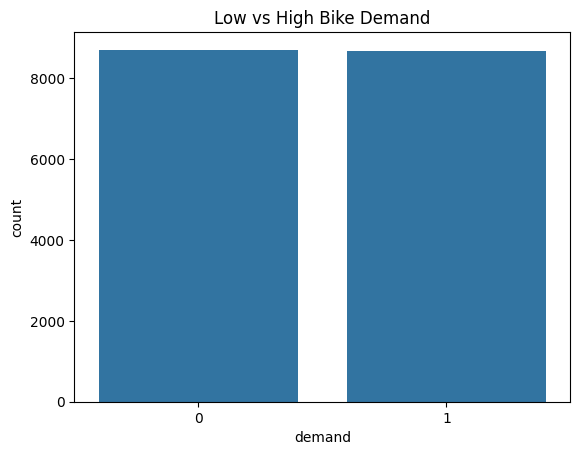

In [9]:
# 6: Visualization
sns.countplot(x='demand', data=df)
plt.title("Low vs High Bike Demand")
plt.show()


In [10]:
# 7: Encoding (if needed)
le = LabelEncoder()
for column in df.columns:
    if df[column].dtype == 'object':
        df[column] = le.fit_transform(df[column])

In [11]:
# 8: Features & Target
X = df.drop("demand", axis=1)
y = df["demand"]


In [12]:
# 9: Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [13]:
# Result storage
results_8020 = []
results_7030 = []

In [14]:
# =========================
# 10: Logistic Regression
# =========================

# 80:20
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
acc_lr_80 = accuracy_score(y_test, lr.predict(X_test))
results_8020.append(['Logistic Regression', acc_lr_80])

In [15]:
# 70:30
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)
lr.fit(X_train, y_train)
acc_lr_70 = accuracy_score(y_test, lr.predict(X_test))
results_7030.append(['Logistic Regression', acc_lr_70])

In [16]:
# =========================
# 11: Decision Tree
# =========================

# 80:20
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
acc_dt_80 = accuracy_score(y_test, dt.predict(X_test))
results_8020.append(['Decision Tree', acc_dt_80])

# 70:30
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)
dt.fit(X_train, y_train)
acc_dt_70 = accuracy_score(y_test, dt.predict(X_test))
results_7030.append(['Decision Tree', acc_dt_70])

# =========================
# 12: Random Forest
# =========================

# 80:20
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)
acc_rf_80 = accuracy_score(y_test, rf.predict(X_test))
results_8020.append(['Random Forest', acc_rf_80])

# 70:30
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)
rf.fit(X_train, y_train)
acc_rf_70 = accuracy_score(y_test, rf.predict(X_test))
results_7030.append(['Random Forest', acc_rf_70])

# =========================
# 13: SVM
# =========================

# 80:20
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
svm = SVC()
svm.fit(X_train, y_train)
acc_svm_80 = accuracy_score(y_test, svm.predict(X_test))
results_8020.append(['SVM', acc_svm_80])

# 70:30
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)
svm.fit(X_train, y_train)
acc_svm_70 = accuracy_score(y_test, svm.predict(X_test))
results_7030.append(['SVM', acc_svm_70])

# =========================
# 14: KNN
# =========================

# 80:20
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
acc_knn_80 = accuracy_score(y_test, knn.predict(X_test))
results_8020.append(['KNN', acc_knn_80])

# 70:30
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)
knn.fit(X_train, y_train)
acc_knn_70 = accuracy_score(y_test, knn.predict(X_test))
results_7030.append(['KNN', acc_knn_70])

# =========================
# 15: Naive Bayes
# =========================

# 80:20
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
nb = GaussianNB()
nb.fit(X_train, y_train)
acc_nb_80 = accuracy_score(y_test, nb.predict(X_test))
results_8020.append(['Naive Bayes', acc_nb_80])

# 70:30
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)
nb.fit(X_train, y_train)
acc_nb_70 = accuracy_score(y_test, nb.predict(X_test))
results_7030.append(['Naive Bayes', acc_nb_70])

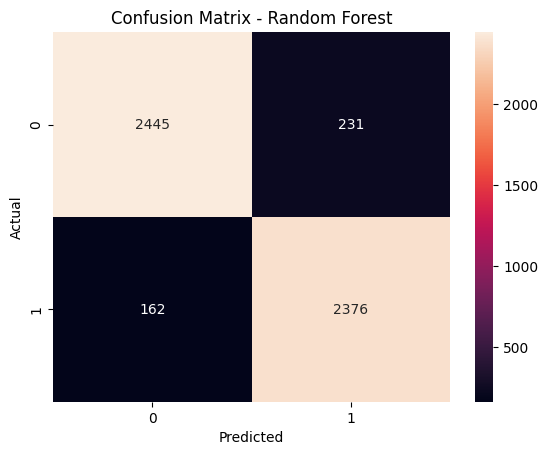

In [17]:
# =========================
# 16: Confusion Matrix
# =========================

cm = confusion_matrix(y_test, rf.predict(X_test))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [18]:
# =========================
# 17: Metrics
# =========================

print("Precision:", precision_score(y_test, rf.predict(X_test)))
print("Recall:", recall_score(y_test, rf.predict(X_test)))
print("F1 Score:", f1_score(y_test, rf.predict(X_test)))


Precision: 0.9113924050632911
Recall: 0.9361702127659575
F1 Score: 0.9236151603498542


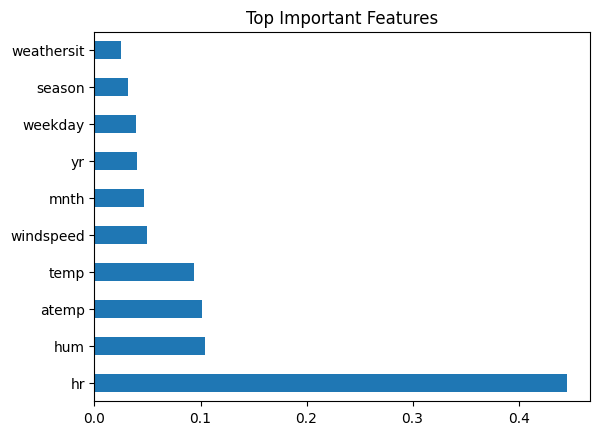

In [19]:
# =========================
# 18: Feature Importance
# =========================

importances = rf.feature_importances_
feature_names = X.columns
feature_imp = pd.Series(importances, index=feature_names)

feature_imp.nlargest(10).plot(kind='barh')
plt.title("Top Important Features")
plt.show()

In [20]:
# =========================
# 19: Final Tables
# =========================

df_8020 = pd.DataFrame(results_8020, columns=['Model', 'Accuracy'])
df_7030 = pd.DataFrame(results_7030, columns=['Model', 'Accuracy'])

print("\n==============================")
print("80:20 SPLIT PERFORMANCE")
print("==============================")
print(df_8020)

print("\n==============================")
print("70:30 SPLIT PERFORMANCE")
print("==============================")
print(df_7030)


80:20 SPLIT PERFORMANCE
                 Model  Accuracy
0  Logistic Regression  0.781646
1        Decision Tree  0.909091
2        Random Forest  0.922900
3                  SVM  0.881185
4                  KNN  0.844074
5          Naive Bayes  0.792290

70:30 SPLIT PERFORMANCE
                 Model  Accuracy
0  Logistic Regression  0.791715
1        Decision Tree  0.909091
2        Random Forest  0.924626
3                  SVM  0.882048
4                  KNN  0.844265
5          Naive Bayes  0.797660


In [24]:
# =========================
# Final Classification Metrics
# =========================

from sklearn.metrics import precision_score, recall_score, f1_score

models = {
    "Decision Tree": dt,
    "Random Forest": rf,
    "SVM": svm,
    "KNN": knn,
    "Naive Bayes": nb
}

print("\n===== Classification Metrics (80:20 Split) =====")

# Use last 80:20 split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"\n{name}:")
    print("Precision:", precision_score(y_test, y_pred, average='weighted'))
    print("Recall   :", recall_score(y_test, y_pred, average='weighted'))
    print("F1 Score :", f1_score(y_test, y_pred, average='weighted'))


===== Classification Metrics (80:20 Split) =====

Decision Tree:
Precision: 0.9128400320803226
Recall   : 0.9128308400460299
F1 Score : 0.912833546725471

Random Forest:
Precision: 0.9267368852089247
Recall   : 0.9266398158803222
F1 Score : 0.9266477778471918

SVM:
Precision: 0.8812484986668416
Recall   : 0.8811852704257768
F1 Score : 0.8811958056286667

KNN:
Precision: 0.8440672070235832
Recall   : 0.8440736478711163
F1 Score : 0.8440693092377227

Naive Bayes:
Precision: 0.7930913279465279
Recall   : 0.7922899884925202
F1 Score : 0.7919500800110252


In [25]:
# =========================
# Regression Models + Evaluation
# =========================

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Train-test split (use once)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Models
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree Regressor": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=100),
    "Gradient Boosting Regressor": GradientBoostingRegressor(),
    "SVR": SVR(),
    "KNN Regressor": KNeighborsRegressor(n_neighbors=5)
}

# Evaluation
print("===== Regression Model Performance =====")

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    print(f"\n{name}:")
    print("MAE :", mae)
    print("RMSE:", rmse)
    print("R2  :", r2)

===== Regression Model Performance =====

Linear Regression:
MAE : 0.32812796607605127
RMSE: 0.3962678282455221
R2  : 0.37155435283914695

Decision Tree Regressor:
MAE : 0.0903337169159954
RMSE: 0.3005556802258034
R2  : 0.6384736360251788

Random Forest Regressor:
MAE : 0.09553509781357881
RMSE: 0.2126420191504973
R2  : 0.8190376331050492

Gradient Boosting Regressor:
MAE : 0.18331305710657503
RMSE: 0.2696532611464537
R2  : 0.708994332694437

SVR:
MAE : 0.21297249021316866
RMSE: 0.3109555857182476
R2  : 0.6130215168400948

KNN Regressor:
MAE : 0.19884925201380899
RMSE: 0.33011488044662574
R2  : 0.5638656475361074


In [26]:
# =========================
# Regression Models (80:20 and 70:30)
# =========================

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Models
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(n_estimators=100),
    "Gradient Boosting": GradientBoostingRegressor(),
    "SVR": SVR(),
    "KNN": KNeighborsRegressor(n_neighbors=5)
}

# Function to evaluate
def evaluate_split(test_size, split_name):
    print(f"\n===== Results for {split_name} Split =====")

    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=test_size, random_state=42
    )

    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)

        print(f"\n{name}:")
        print("MAE :", mae)
        print("RMSE:", rmse)
        print("R2  :", r2)

# Run for both splits
evaluate_split(0.2, "80:20")
evaluate_split(0.3, "70:30")


===== Results for 80:20 Split =====

Linear Regression:
MAE : 0.32812796607605127
RMSE: 0.3962678282455221
R2  : 0.37155435283914695

Decision Tree:
MAE : 0.08803222094361335
RMSE: 0.29670224290290315
R2  : 0.6476844988016074

Random Forest:
MAE : 0.09621116225546605
RMSE: 0.21323006316862378
R2  : 0.818035376099189

Gradient Boosting:
MAE : 0.18330635975135115
RMSE: 0.26961610936154046
R2  : 0.7090745144444311

SVR:
MAE : 0.21297249021316866
RMSE: 0.3109555857182476
R2  : 0.6130215168400948

KNN:
MAE : 0.19884925201380899
RMSE: 0.33011488044662574
R2  : 0.5638656475361074

===== Results for 70:30 Split =====

Linear Regression:
MAE : 0.32690496313840456
RMSE: 0.3934003190647341
R2  : 0.38051079567813406

Decision Tree:
MAE : 0.0918680475642501
RMSE: 0.30309742256286193
R2  : 0.6322702102923456

Random Forest:
MAE : 0.09846566935174532
RMSE: 0.21685684020710683
R2  : 0.8117605792845608

Gradient Boosting:
MAE : 0.18271796985932862
RMSE: 0.27051109662513634
R2  : 0.7070897990449171

SV

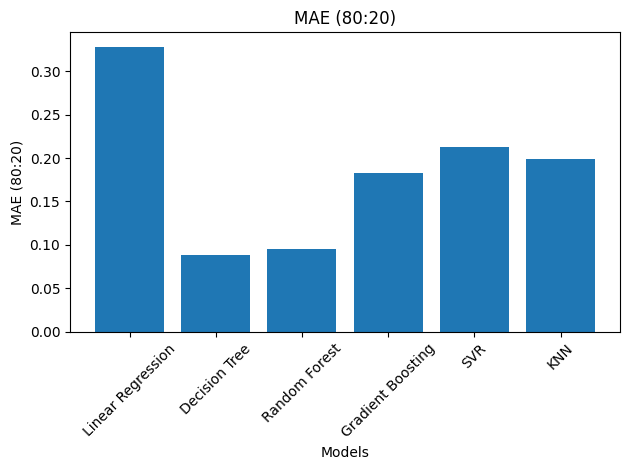

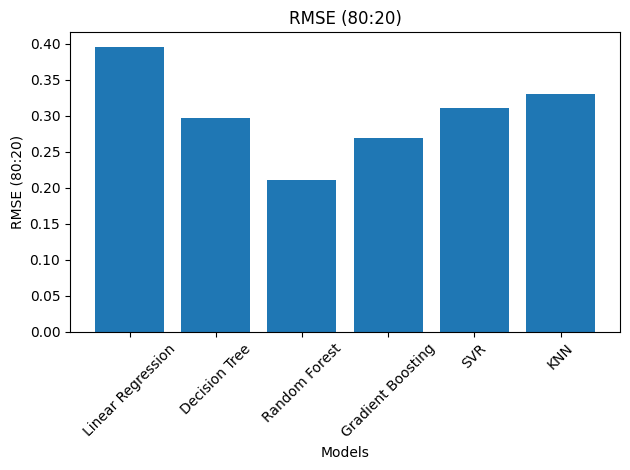

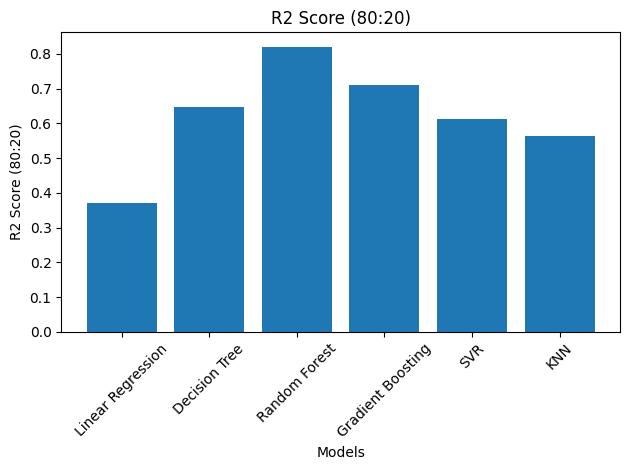

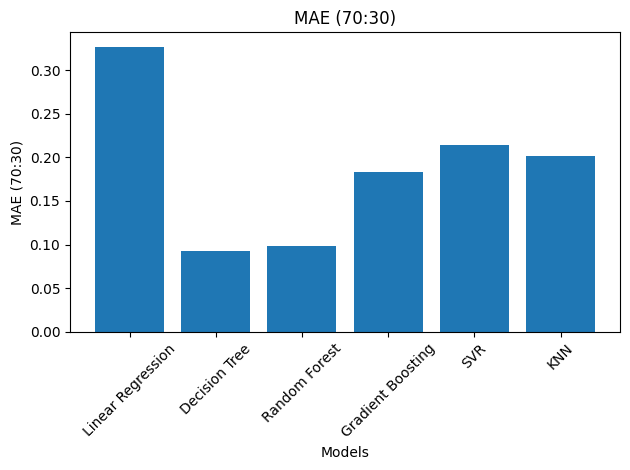

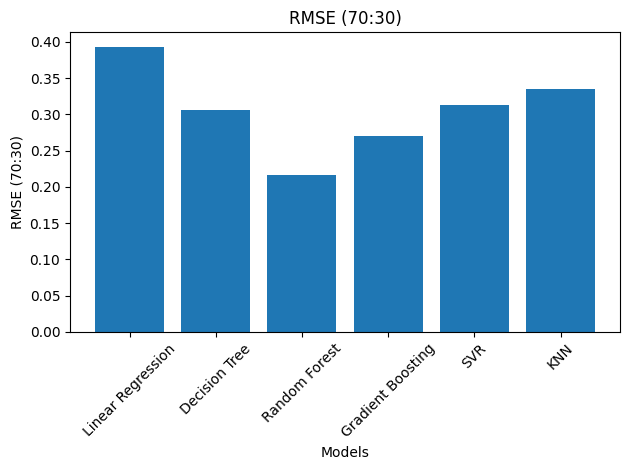

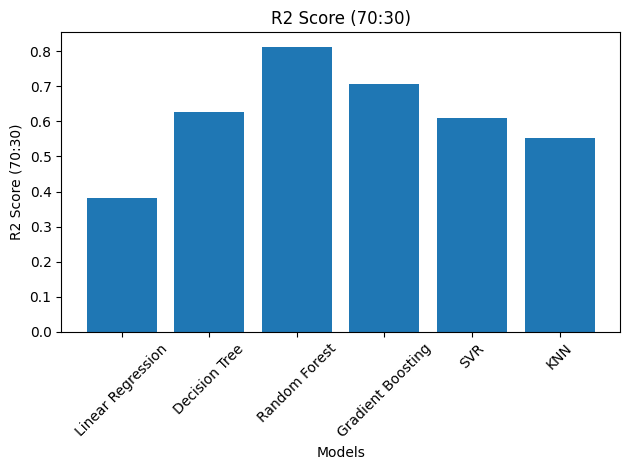

In [27]:
import matplotlib.pyplot as plt

# Store results
results_8020 = []
results_7030 = []

def evaluate_and_store(test_size, results_list):
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=test_size, random_state=42
    )

    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)

        results_list.append([name, mae, rmse, r2])

# Run for both splits
evaluate_and_store(0.2, results_8020)
evaluate_and_store(0.3, results_7030)

# Function to plot
def plot_metric(results, metric_index, title):
    model_names = [r[0] for r in results]
    values = [r[metric_index] for r in results]

    plt.figure()
    plt.bar(model_names, values)
    plt.xticks(rotation=45)
    plt.title(title)
    plt.xlabel("Models")
    plt.ylabel(title)
    plt.tight_layout()
    plt.show()

# Plot graphs for 80:20
plot_metric(results_8020, 1, "MAE (80:20)")
plot_metric(results_8020, 2, "RMSE (80:20)")
plot_metric(results_8020, 3, "R2 Score (80:20)")

# Plot graphs for 70:30
plot_metric(results_7030, 1, "MAE (70:30)")
plot_metric(results_7030, 2, "RMSE (70:30)")
plot_metric(results_7030, 3, "R2 Score (70:30)")

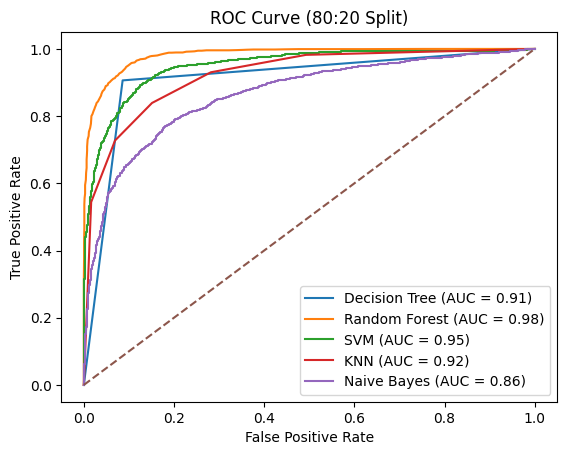

In [28]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Example: using 80:20 split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

models = {
    "Decision Tree": dt,
    "Random Forest": rf,
    "SVM": svm,
    "KNN": knn,
    "Naive Bayes": nb
}

plt.figure()

for name, model in models.items():
    model.fit(X_train, y_train)

    # Get probability scores
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = model.decision_function(X_test)

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

# Plot random line
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (80:20 Split)")
plt.legend()
plt.show()

In [29]:
import pandas as pd

# Create empty lists
results_8020 = []
results_7030 = []

def evaluate_and_store(test_size, results_list):
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=test_size, random_state=42
    )

    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)

        results_list.append([name, mae, rmse, r2])

# Run
evaluate_and_store(0.2, results_8020)
evaluate_and_store(0.3, results_7030)

# Convert to DataFrame
df_8020 = pd.DataFrame(results_8020, columns=["Model", "MAE", "RMSE", "R2"])
df_7030 = pd.DataFrame(results_7030, columns=["Model", "MAE", "RMSE", "R2"])

# Display tables
print("\n===== 80:20 Split Results =====")
print(df_8020)

print("\n===== 70:30 Split Results =====")
print(df_7030)


===== 80:20 Split Results =====
           Model       MAE      RMSE        R2
0  Decision Tree  0.087745  0.296217  0.648836
1  Random Forest  0.076812  0.277151  0.692587
2            SVM  0.118815  0.344695  0.524489
3            KNN  0.155926  0.394875  0.375964
4    Naive Bayes  0.207710  0.455752  0.168720

===== 70:30 Split Results =====
           Model       MAE      RMSE        R2
0  Decision Tree  0.090526  0.300875  0.637644
1  Random Forest  0.077292  0.278014  0.690616
2            SVM  0.117952  0.343441  0.527863
3            KNN  0.155735  0.394632  0.376625
4    Naive Bayes  0.202340  0.449822  0.190073
